<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-weight:bold;font-family:Georgia,serif'>Suivre une évolution — Météo</div></th></tr></table>
<table><tr><th><div style='padding:15px;color:#e50000;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>Comment cela évolue-t-il ?</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_2.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_2_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 02 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Lecture de l’année 2024 uniquement, modifiable par ANNEE. Aucun dictionnaire d’unités n’est fourni : les valeurs sont compatibles avec °C, %, m/s et hPa, mais les axes conservent « unité source ». Les plages de contrôle sont des hypothèses exploratoires explicites, à valider avec le producteur. Les hors-plage sont masquées par variable et comptées, sans supprimer toute la ligne. Une moyenne entre stations n’est pas une moyenne climatique territoriale.

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Courbe temporelle
2. Aire simple
3. Courbe en escalier
4. Sparkline ou mini courbe
5. Calendrier thermique
6. Courbe avec bande

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '02_meteo'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

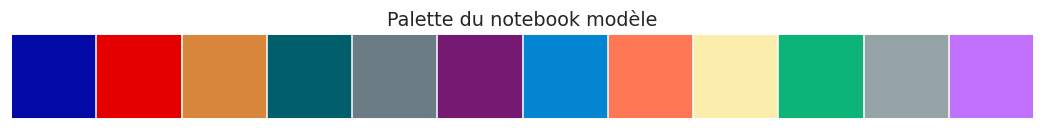

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>Station</td><td>Identifiant de station conservé en texte</td></tr><tr><td>DateHeure</td><td>Date de mesure sans fuseau documenté</td></tr><tr><td>Temperature / Humidite</td><td>Température et humidité dans les unités du fichier</td></tr><tr><td>VitesseVent / Pression</td><td>Mesures dans les unités du fichier</td></tr><tr><td>regime</td><td>Classe dérivée : température <10, de 10 à <20, ou ≥20</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['meteo']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
ANNEE = 2024
colonnes = ['Station', 'DateHeure', 'Temperature', 'Humidite', 'VitesseVent', 'Pression']
brut = pd.read_parquet(CHEMINS['meteo'],
                       filters=[('Annee', '==', ANNEE)]).drop(columns='Station').rename(columns={'Nom':'Station'})[colonnes]
donnees = brut.copy()
donnees['DateHeure'] = pd.to_datetime(donnees['DateHeure'], errors='coerce')
donnees = donnees.dropna(subset=['Station', 'DateHeure'])
print('Lignes source sur l’année :', len(brut), '; dates/stations absentes :', len(brut)-len(donnees))
print('Doublons station/date conservés et signalés :', donnees.duplicated(['Station','DateHeure']).sum())
# Pas de suppression automatique des doublons : plusieurs mesures peuvent être légitimes.
regles = {'Temperature': (-90, 60), 'Humidite': (0, 100), 'VitesseVent': (0, 150), 'Pression': (500, 1100)}
audit = []
for col, (bas, haut) in regles.items():
    donnees[col] = pd.to_numeric(donnees[col], errors='coerce')
    hors = donnees[col].notna() & ~donnees[col].between(bas, haut)
    audit.append([col, int(donnees[col].isna().sum()), int(hors.sum())])
    donnees.loc[hors, col] = np.nan
display(pd.DataFrame(audit, columns=['Variable','Absentes','Hors plage masquées']))
donnees['mois'] = donnees['DateHeure'].dt.month
donnees['jour'] = donnees['DateHeure'].dt.floor('D')
# Classes pédagogiques dans l’unité de température du fichier.
donnees['regime'] = pd.cut(donnees['Temperature'], [-np.inf,10,20,np.inf],
                           labels=['< 10', '10 à < 20', '≥ 20'], right=False)
stations = donnees.groupby('Station')['Temperature'].count().nlargest(6).index.tolist()
assert len(stations) >= 3
station = stations[0]
print('Année :', ANNEE, '; station principale :', station, '; stations retenues :', stations)
display(donnees.select_dtypes('number').describe().T)

Lignes source sur l’année : 122295 ; dates/stations absentes : 0
Doublons station/date conservés et signalés : 0


,Variable,Absentes,Hors plage masquées
0,Temperature,3042,0
1,Humidite,3346,0
2,VitesseVent,143,0
3,Pression,3432,0


Année : 2024 ; station principale : Alencon ; stations retenues : ['Alencon', 'Bale', 'Le Puy', 'Lille', 'Lyon', 'Nancy']


,count,mean,std,min,25%,50%,75%,max
Temperature,119253.0,13.311918,6.834883,-12.1,8.8,13.0,17.7,38.7
Humidite,118949.0,78.363618,16.311435,1.0,68.0,82.0,92.0,100.0
VitesseVent,122152.0,3.754066,2.591127,0.0,1.9,3.1,5.0,27.0
Pression,118863.0,995.395800,25.643462,888.5,985.9,1002.7,1012.2,1037.7
mois,122295.0,6.515181,3.452406,1.0,4.0,7.0,10.0,12.0


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Courbe temporelle</div></b>

Suivre la température moyenne quotidienne de la station retenue. Variables : jour T + température Q. Les journées absentes restent des ruptures.

In [5]:
d=donnees.loc[donnees.Station.eq(station)].copy()
a=d.groupby('jour').agg(moyenne=('Temperature','mean'),q10=('Temperature',lambda x:x.quantile(.1)),q90=('Temperature',lambda x:x.quantile(.9)),n=('Temperature','count')).reset_index()
a=a.set_index('jour').reindex(pd.date_range(f'{ANNEE}-01-01',f'{ANNEE}-12-31',name='jour')).reset_index()
display(a.head())

,jour,moyenne,q10,q90,n
0,2024-01-01,7.5625,5.19,9.76,8
1,2024-01-02,11.8125,11.17,12.44,8
2,2024-01-03,10.3500,9.65,10.86,8
3,2024-01-04,8.8125,6.86,10.76,8
4,2024-01-05,6.5500,5.17,8.63,8


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

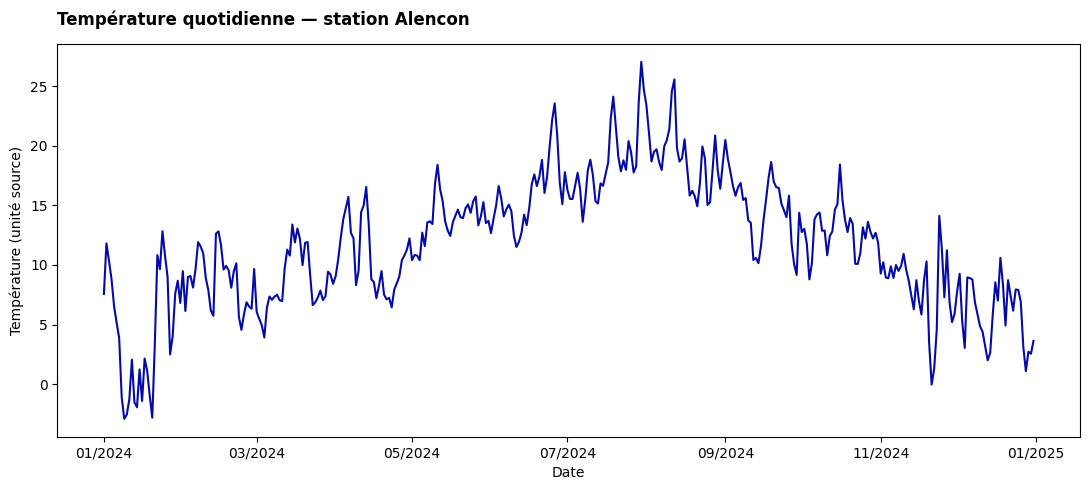

In [6]:
ID_GRAPHIQUE = '02_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.plot(a.jour,a.moyenne,color=palette[0]);ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
terminer(ax,f'Température quotidienne — station {station}','Date','Température (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

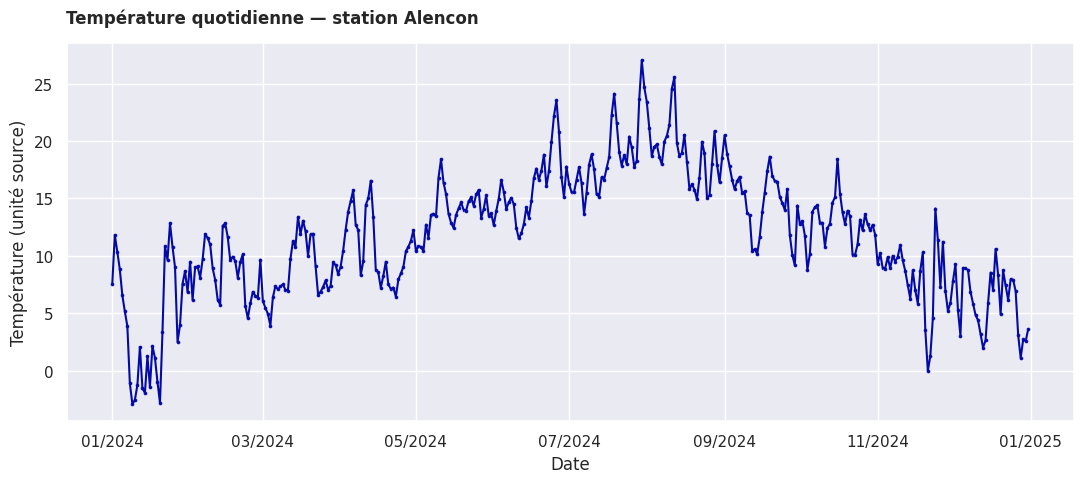

In [7]:
ID_GRAPHIQUE = '02_01'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
# Matplotlib préserve les NaN ; Seaborn peut les supprimer avant de relier les points.
sns.scatterplot(data=a,x='jour',y='moyenne',s=8,color=palette[0],ax=ax)
ax.plot(a.jour,a.moyenne,color=palette[0]);ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
terminer(ax,f'Température quotidienne — station {station}','Date','Température (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [8]:
ID_GRAPHIQUE = '02_01'
BIBLIOTHEQUE = 'plotly'
fig=px.line(a,x='jour',y='moyenne',labels={'jour':'Date','moyenne':'Température (unité source)'})
fig.update_traces(connectgaps=False)
montrer_plotly(fig,f'Température quotidienne — station {station}')

**À lire dans les trois variantes :** Suivre la température moyenne quotidienne de la station retenue. Variables : jour T + température Q. Les journées absentes restent des ruptures.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Aire simple</div></b>

Visualiser le nombre quotidien de mesures de température disponibles pour une station. Variables : jour T + effectif Q. Le zéro signifie absence de mesure disponible, pas température nulle.

In [9]:
d=donnees.loc[donnees.Station.eq(station)].copy()
a=d.groupby('jour').agg(moyenne=('Temperature','mean'),q10=('Temperature',lambda x:x.quantile(.1)),q90=('Temperature',lambda x:x.quantile(.9)),n=('Temperature','count')).reset_index()
a=a.set_index('jour').reindex(pd.date_range(f'{ANNEE}-01-01',f'{ANNEE}-12-31',name='jour')).reset_index()
a['n']=a['n'].fillna(0)
display(a[['jour','n']].head())

,jour,n
0,2024-01-01,8
1,2024-01-02,8
2,2024-01-03,8
3,2024-01-04,8
4,2024-01-05,8


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

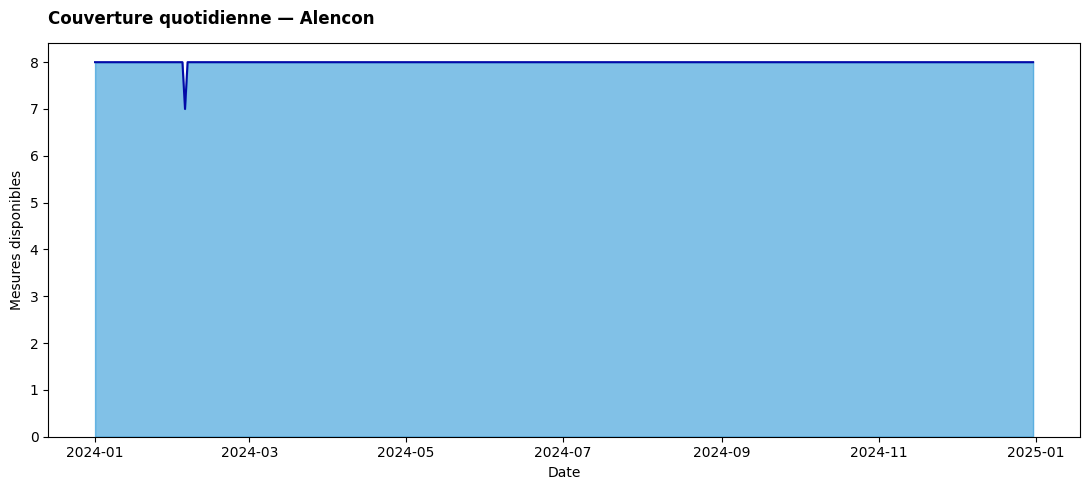

In [10]:
ID_GRAPHIQUE = '02_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.fill_between(a.jour,a.n,alpha=.5,color=palette[6]);ax.plot(a.jour,a.n,color=palette[0]);ax.set_ylim(bottom=0)
terminer(ax,f'Couverture quotidienne — {station}','Date','Mesures disponibles')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

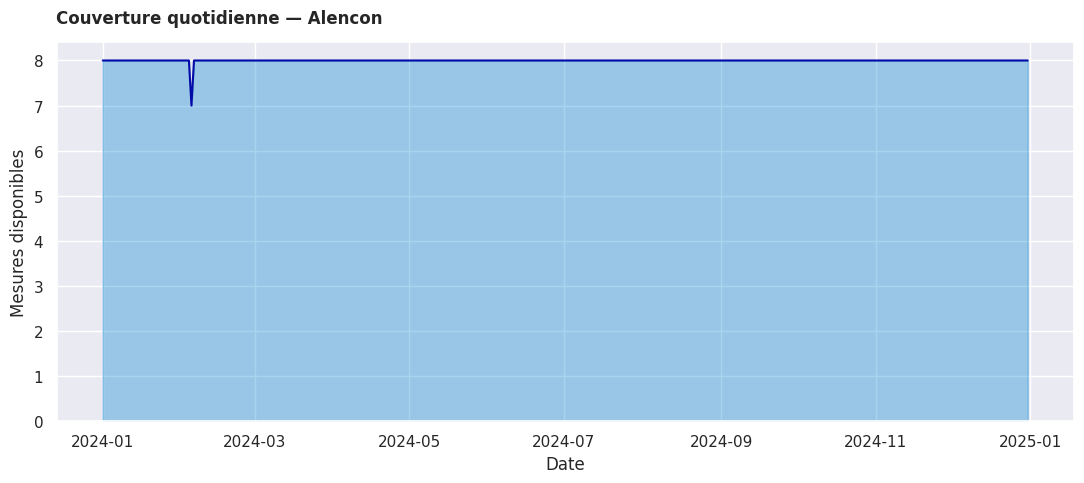

In [11]:
ID_GRAPHIQUE = '02_02'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.fill_between(a.jour,a.n,alpha=.35,color=palette[6]);sns.lineplot(data=a,x='jour',y='n',estimator=None,color=palette[0],ax=ax);ax.set_ylim(bottom=0)
terminer(ax,f'Couverture quotidienne — {station}','Date','Mesures disponibles')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [12]:
ID_GRAPHIQUE = '02_02'
BIBLIOTHEQUE = 'plotly'
fig=px.area(a,x='jour',y='n',labels={'jour':'Date','n':'Mesures disponibles'})
montrer_plotly(fig,f'Couverture quotidienne — {station}')

**À lire dans les trois variantes :** Visualiser le nombre quotidien de mesures de température disponibles pour une station. Variables : jour T + effectif Q. Le zéro signifie absence de mesure disponible, pas température nulle.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Courbe en escalier</div></b>

Représenter la dernière mesure d’humidité comme valeur maintenue jusqu’au relevé suivant, sur les trois premiers jours. Variables : date T + humidité Q. Ce maintien est une convention d’affichage, pas une mesure continue.

In [13]:
d=donnees.loc[donnees.Station.eq(station)].sort_values('DateHeure')
a=d.loc[d.DateHeure.lt(d.DateHeure.min()+pd.Timedelta(days=3)),['DateHeure','Humidite']].dropna()
display(a.head())

,DateHeure,Humidite
26317,2024-01-01 00:00:00,82.0
26318,2024-01-01 03:00:00,79.0
26319,2024-01-01 06:00:00,86.0
26320,2024-01-01 09:00:00,93.0
26321,2024-01-01 12:00:00,75.0


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

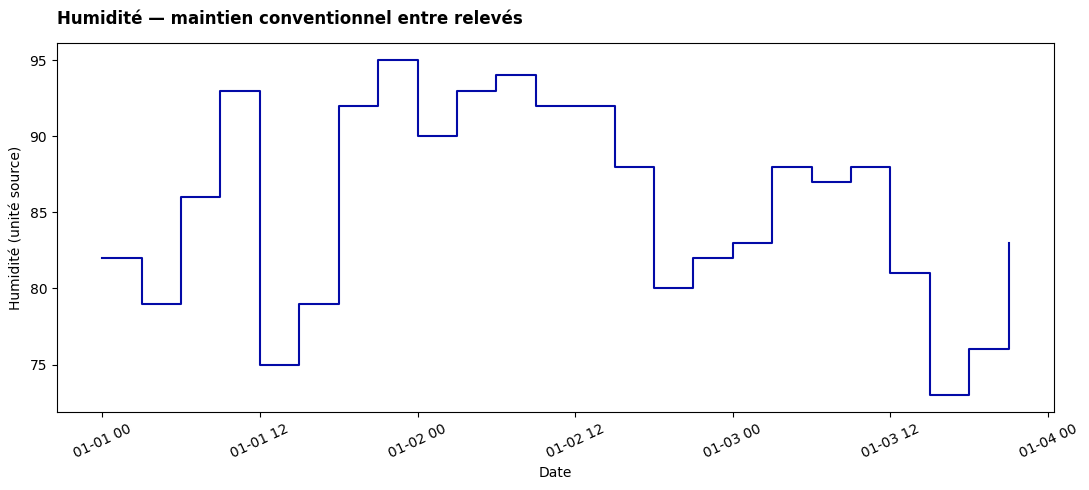

In [14]:
ID_GRAPHIQUE = '02_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.step(a.DateHeure,a.Humidite,where='post',color=palette[0]);ax.tick_params(axis='x',rotation=25)
terminer(ax,'Humidité — maintien conventionnel entre relevés','Date','Humidité (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

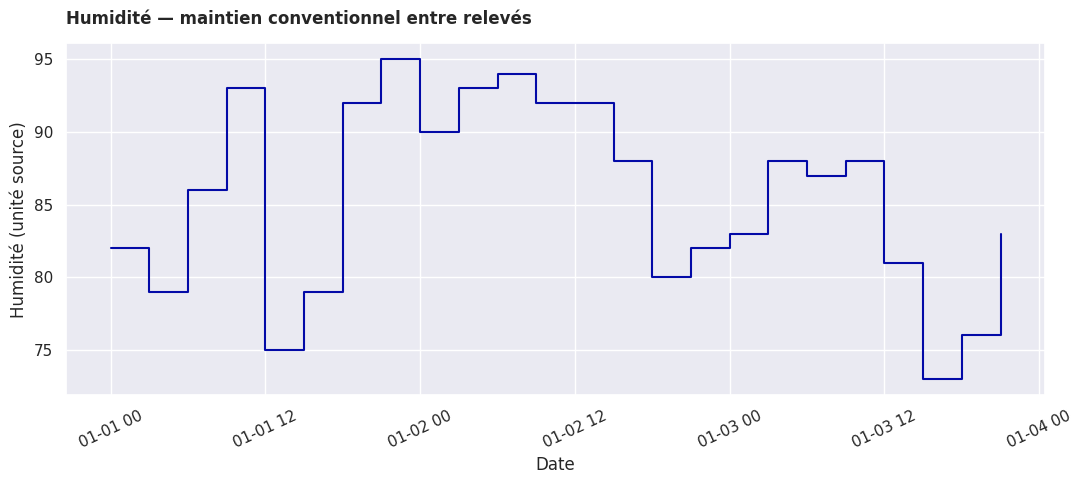

In [15]:
ID_GRAPHIQUE = '02_03'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.lineplot(data=a,x='DateHeure',y='Humidite',estimator=None,drawstyle='steps-post',color=palette[0],ax=ax);ax.tick_params(axis='x',rotation=25)
terminer(ax,'Humidité — maintien conventionnel entre relevés','Date','Humidité (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [16]:
ID_GRAPHIQUE = '02_03'
BIBLIOTHEQUE = 'plotly'
fig=px.line(a,x='DateHeure',y='Humidite',line_shape='hv',labels={'DateHeure':'Date','Humidite':'Humidité (unité source)'})
montrer_plotly(fig,'Humidité — maintien conventionnel entre relevés')

**À lire dans les trois variantes :** Représenter la dernière mesure d’humidité comme valeur maintenue jusqu’au relevé suivant, sur les trois premiers jours. Variables : date T + humidité Q. Ce maintien est une convention d’affichage, pas une mesure continue.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Sparklines</div></b>

Comparer les tendances mensuelles des quatre stations les mieux renseignées. Variables : station C + mois T + température Q. Une échelle verticale commune permet la comparaison.

In [17]:
a=donnees.loc[donnees.Station.isin(stations[:4])].groupby(['Station','mois']).Temperature.mean().unstack('Station').reindex(range(1,13))
display(a)

Station,Alencon,Bale,Le Puy,Lille
mois,,,,
1,4.193145,2.956048,2.622984,3.783468
2,8.758874,8.307359,5.141991,8.716883
3,8.559677,9.102016,6.395161,9.100806
4,10.637083,10.997500,8.088333,11.067500
5,13.834677,15.144758,11.097177,15.029839
6,16.002083,18.858333,15.814583,16.230417
7,18.544355,21.150806,18.828226,19.272984
8,18.962500,22.358871,19.450000,20.023387
9,14.815833,15.610833,12.654167,15.896250


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

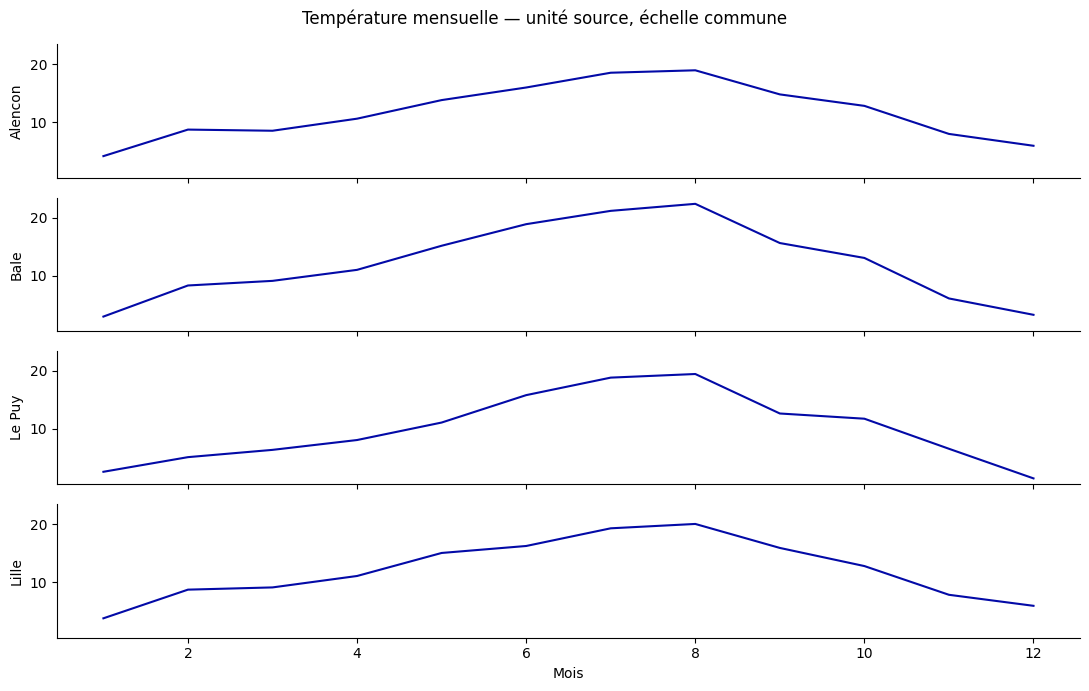

In [18]:
ID_GRAPHIQUE = '02_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,axes=plt.subplots(4,1,figsize=(11,7),sharex=True,sharey=True)
for ax,col in zip(axes,a):
    ax.plot(a.index,a[col],color=palette[0]);ax.set_ylabel(col);ax.spines[['top','right']].set_visible(False)
fig.suptitle('Température mensuelle — unité source, échelle commune');axes[-1].set_xlabel('Mois');fig.tight_layout();sauvegarderImage(ID_GRAPHIQUE+'_matplotlib',fig);plt.show();plt.close(fig)

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

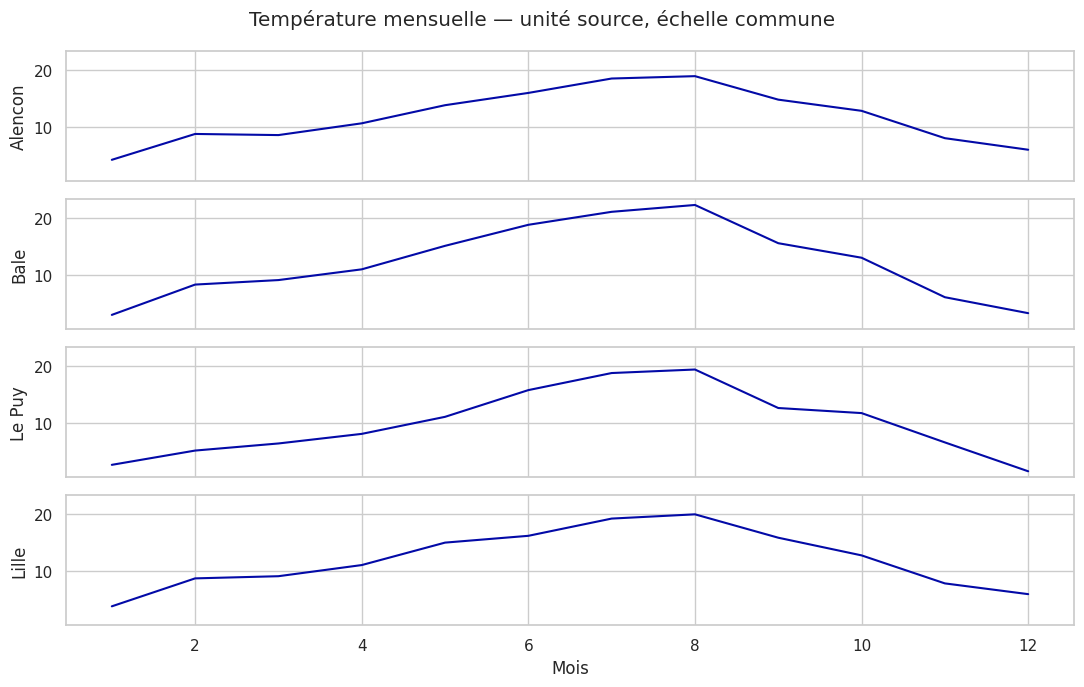

In [19]:
ID_GRAPHIQUE = '02_04'
BIBLIOTHEQUE = 'seaborn'
sns.set_theme(style='whitegrid',palette=palette)
fig,axes=plt.subplots(4,1,figsize=(11,7),sharex=True,sharey=True)
for ax,col in zip(axes,a):
    sns.lineplot(x=a.index,y=a[col],estimator=None,ax=ax,color=palette[0]);ax.set_ylabel(col)
fig.suptitle('Température mensuelle — unité source, échelle commune');axes[-1].set_xlabel('Mois');fig.tight_layout();sauvegarderImage(ID_GRAPHIQUE+'_seaborn',fig);plt.show();plt.close(fig)

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [20]:
ID_GRAPHIQUE = '02_04'
BIBLIOTHEQUE = 'plotly'
fig=make_subplots(rows=4,cols=1,shared_xaxes=True,shared_yaxes=True,subplot_titles=list(a.columns))
for i,col in enumerate(a):fig.add_trace(go.Scatter(x=a.index,y=a[col],name=col,showlegend=False),row=i+1,col=1)
fig.update_yaxes(range=[float(a.min().min())-1,float(a.max().max())+1]);fig.update_xaxes(title_text='Mois',row=4,col=1)
montrer_plotly(fig,'Température mensuelle — unité source, échelle commune')

**À lire dans les trois variantes :** Comparer les tendances mensuelles des quatre stations les mieux renseignées. Variables : station C + mois T + température Q. Une échelle verticale commune permet la comparaison.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Calendrier thermique</div></b>

Repérer la saisonnalité quotidienne de température. Variables : date T + température Q. Les cases blanches représentent les données absentes ou les jours hors année.

In [21]:
d=donnees.loc[donnees.Station.eq(station)].copy()
a=d.groupby('jour').agg(moyenne=('Temperature','mean'),q10=('Temperature',lambda x:x.quantile(.1)),q90=('Temperature',lambda x:x.quantile(.9)),n=('Temperature','count')).reset_index()
a=a.set_index('jour').reindex(pd.date_range(f'{ANNEE}-01-01',f'{ANNEE}-12-31',name='jour')).reset_index()
a['semaine']=(a.jour-pd.Timestamp(f'{ANNEE}-01-01')+pd.Timedelta(days=pd.Timestamp(f'{ANNEE}-01-01').weekday())).dt.days//7
a['jour_semaine']=a.jour.dt.weekday
cal=a.pivot(index='jour_semaine',columns='semaine',values='moyenne').reindex(range(7))
jours=['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
display(cal.iloc[:,:5])

semaine,0,1,2,3,4
jour_semaine,,,,,
0,7.5625,-1.1250,1.2250,10.8250,7.5750
1,11.8125,-2.9250,-1.4250,9.6375,8.6750
2,10.3500,-2.5625,2.1375,12.8375,6.8125
3,8.8125,-1.2750,1.1000,10.7750,9.4875
4,6.5500,2.0500,-0.9875,9.0125,6.1375
5,5.1500,-1.5375,-2.8250,2.4875,8.9875
6,3.8625,-1.9500,3.3500,4.0000,9.0750


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

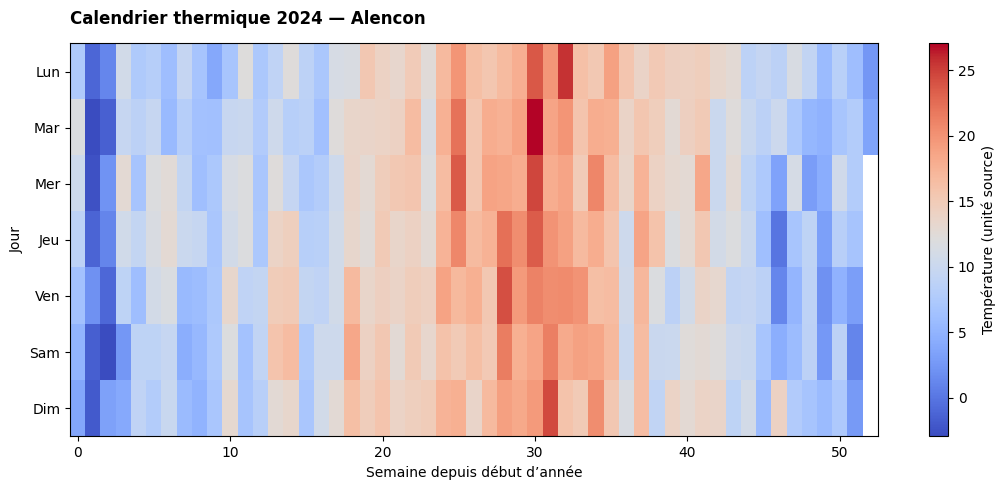

In [22]:
ID_GRAPHIQUE = '02_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
im=ax.imshow(cal,aspect='auto',cmap='coolwarm');ax.set_yticks(range(7),jours);fig.colorbar(im,ax=ax,label='Température (unité source)')
terminer(ax,f'Calendrier thermique {ANNEE} — {station}','Semaine depuis début d’année','Jour')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

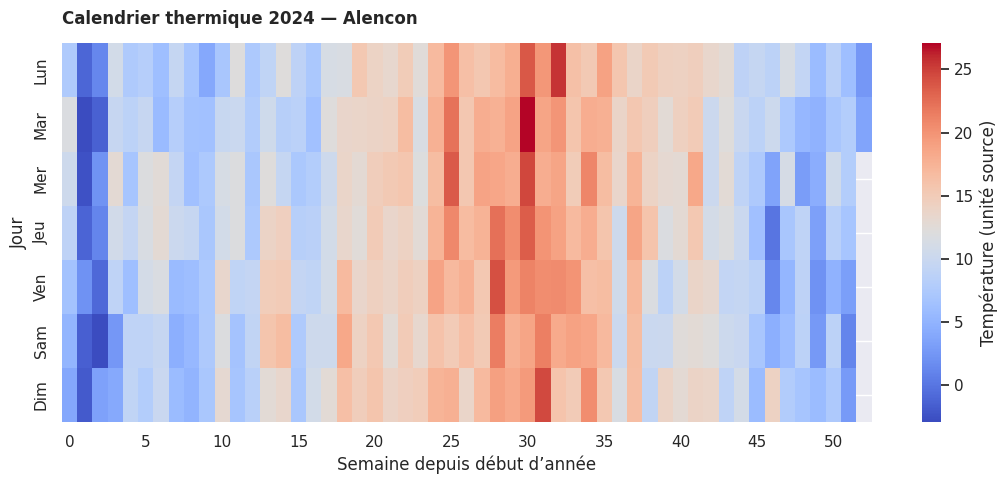

In [23]:
ID_GRAPHIQUE = '02_05'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.heatmap(cal,mask=cal.isna(),cmap='coolwarm',yticklabels=jours,xticklabels=5,cbar_kws={'label':'Température (unité source)'},ax=ax)
terminer(ax,f'Calendrier thermique {ANNEE} — {station}','Semaine depuis début d’année','Jour')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [24]:
ID_GRAPHIQUE = '02_05'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Heatmap(z=cal.to_numpy(),x=cal.columns,y=jours,colorscale='RdBu_r',colorbar_title='Unité source',hoverongaps=False))
fig.update_layout(xaxis_title='Semaine depuis début d’année',yaxis_autorange='reversed')
montrer_plotly(fig,f'Calendrier thermique {ANNEE} — {station}')

**À lire dans les trois variantes :** Repérer la saisonnalité quotidienne de température. Variables : date T + température Q. Les cases blanches représentent les données absentes ou les jours hors année.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Courbe avec bande</div></b>

Afficher moyenne et intervalle P10–P90 des mesures intrajournalières. Variables : date T + moyenne Q + deux bornes Q. La bande décrit une dispersion observée ; ce n’est ni une prévision ni un intervalle de confiance.

In [25]:
d=donnees.loc[donnees.Station.eq(station)].copy()
a=d.groupby('jour').agg(moyenne=('Temperature','mean'),q10=('Temperature',lambda x:x.quantile(.1)),q90=('Temperature',lambda x:x.quantile(.9)),n=('Temperature','count')).reset_index()
a=a.set_index('jour').reindex(pd.date_range(f'{ANNEE}-01-01',f'{ANNEE}-12-31',name='jour')).reset_index()
a=a.iloc[:90]
display(a.head())

,jour,moyenne,q10,q90,n
0,2024-01-01,7.5625,5.19,9.76,8
1,2024-01-02,11.8125,11.17,12.44,8
2,2024-01-03,10.3500,9.65,10.86,8
3,2024-01-04,8.8125,6.86,10.76,8
4,2024-01-05,6.5500,5.17,8.63,8


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

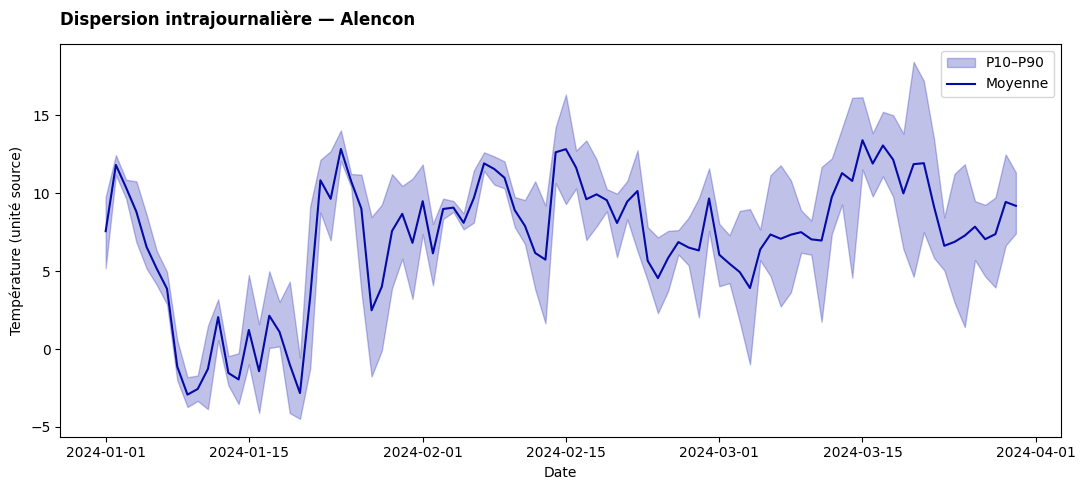

In [26]:
ID_GRAPHIQUE = '02_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.fill_between(a.jour,a.q10,a.q90,alpha=.25,color=palette[0],label='P10–P90');ax.plot(a.jour,a.moyenne,color=palette[0],label='Moyenne');ax.legend()
terminer(ax,f'Dispersion intrajournalière — {station}','Date','Température (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

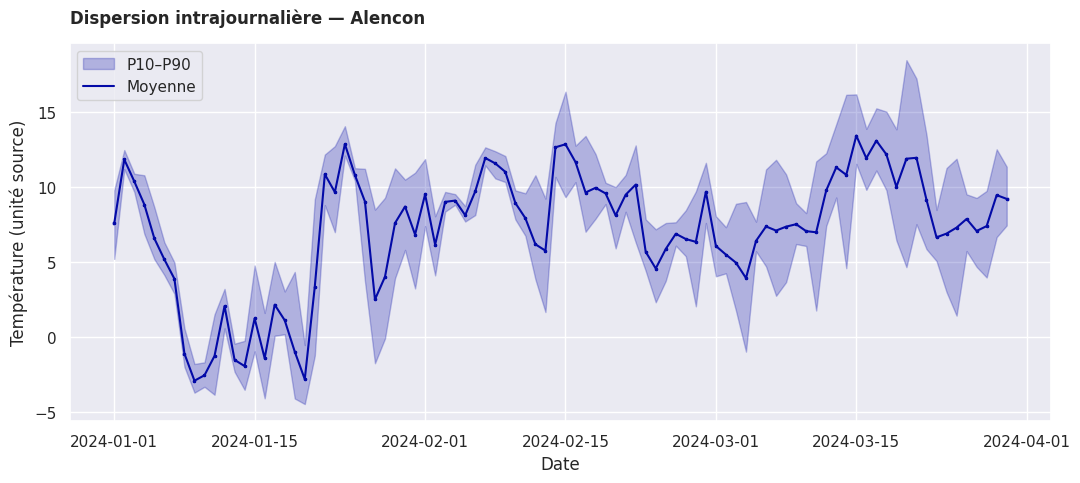

In [27]:
ID_GRAPHIQUE = '02_06'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.fill_between(a.jour,a.q10,a.q90,alpha=.25,color=palette[0],label='P10–P90');sns.scatterplot(data=a,x='jour',y='moyenne',s=10,color=palette[0],ax=ax);ax.plot(a.jour,a.moyenne,label='Moyenne',color=palette[0]);ax.legend()
terminer(ax,f'Dispersion intrajournalière — {station}','Date','Température (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [28]:
ID_GRAPHIQUE = '02_06'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
fig.add_trace(go.Scatter(x=a.jour,y=a.q90,line_width=0,name='P90',showlegend=False))
fig.add_trace(go.Scatter(x=a.jour,y=a.q10,fill='tonexty',line_width=0,fillcolor='rgba(3,10,167,.2)',name='P10–P90'))
fig.add_trace(go.Scatter(x=a.jour,y=a.moyenne,name='Moyenne',line_color=palette[0]))
fig.update_layout(xaxis_title='Date',yaxis_title='Température (unité source)')
montrer_plotly(fig,f'Dispersion intrajournalière — {station}')

**À lire dans les trois variantes :** Afficher moyenne et intervalle P10–P90 des mesures intrajournalières. Variables : date T + moyenne Q + deux bornes Q. La bande décrit une dispersion observée ; ce n’est ni une prévision ni un intervalle de confiance.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Lecture de l’année 2024 uniquement, modifiable par ANNEE. Aucun dictionnaire d’unités n’est fourni : les valeurs sont compatibles avec °C, %, m/s et hPa, mais les axes conservent « unité source ». Les plages de contrôle sont des hypothèses exploratoires explicites, à valider avec le producteur. Les hors-plage sont masquées par variable et comptées, sans supprimer toute la ligne. Une moyenne entre stations n’est pas une moyenne climatique territoriale.